# NB1 — SFT-mini: Build the Lab 21 SFT checkpoint inline

**Stack:** Unsloth + LoRA r=16 + bitsandbytes 4-bit base + 1k VN Alpaca, 1 epoch.
Maps to deck §1 (why SFT alone insufficient — motivates the upcoming DPO step) +
deck §3 (DPO will need this SFT checkpoint as initial policy).

> **Mục tiêu:** tạo 1 SFT adapter "đủ tốt" để DPO có gì align lên. Đây là
> Lab 21 thu gọn — nếu bạn đã hoàn thành Lab 21 sibling repo
> ([VinUni-AI20k/Day21-Track3-Finetuning-LLMs-LoRA-QLoRA](https://github.com/VinUni-AI20k/Day21-Track3-Finetuning-LLMs-LoRA-QLoRA)),
> bạn có thể SKIP notebook này và copy adapter cũ vào `adapters/sft-mini/`.
>
> Nếu chưa, notebook này build từ đầu trong ~10 phút trên T4 (15 phút trên Colab CPU runtime — *đừng làm vậy*).

## 0. Setup

In [1]:
import os
from pathlib import Path

# Tier detection. Defaults to T4 if env not set.
COMPUTE_TIER = os.environ.get("COMPUTE_TIER", "T4").upper()
assert COMPUTE_TIER in ("T4", "BIGGPU"), f"Invalid COMPUTE_TIER: {COMPUTE_TIER}"

# Tier-specific hyperparameters
if COMPUTE_TIER == "T4":
    BASE_MODEL = "unsloth/Qwen2.5-3B-Instruct-bnb-4bit"
    MAX_LEN = 512
    PER_DEVICE_BATCH = 1
    GRAD_ACCUM = 8
else:  # BIGGPU
    BASE_MODEL = "unsloth/Qwen2.5-7B-Instruct-bnb-4bit"
    MAX_LEN = 1024
    PER_DEVICE_BATCH = 2
    GRAD_ACCUM = 4

SFT_DATASET = os.environ.get("SFT_DATASET", "5CD-AI/Vietnamese-alpaca-cleaned")
SFT_SLICE = 1000
NUM_EPOCHS = 1

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
ADAPTER_OUT = REPO_ROOT / "adapters" / "sft-mini"
ADAPTER_OUT.mkdir(parents=True, exist_ok=True)

print(f"COMPUTE_TIER:    {COMPUTE_TIER}")
print(f"BASE_MODEL:      {BASE_MODEL}")
print(f"SFT_DATASET:     {SFT_DATASET}  (slice: {SFT_SLICE})")
print(f"max_seq_length:  {MAX_LEN}")
print(f"effective batch: {PER_DEVICE_BATCH * GRAD_ACCUM}")
print(f"output:          {ADAPTER_OUT}")

COMPUTE_TIER:    BIGGPU
BASE_MODEL:      unsloth/Qwen2.5-7B-Instruct-bnb-4bit
SFT_DATASET:     bkai-foundation-models/vi-alpaca  (slice: 1000)
max_seq_length:  1024
effective batch: 8
output:          /__modal/volumes/vo-QbF7K8KWuDIUX0zRCoBH8Z/lab22/adapters/sft-mini


In [2]:
import torch

assert torch.cuda.is_available(), "DPO needs a CUDA GPU. See HARDWARE-GUIDE.md."
gpu = torch.cuda.get_device_properties(0)
print(f"GPU: {gpu.name}  ({gpu.total_memory / 1e9:.1f} GB)")

GPU: NVIDIA L4  (23.7 GB)


## 1. Load base model with Unsloth

Unsloth bundles patched 4-bit kernels — that's how Qwen2.5-3B (or 7B) stays
in T4 / A100 budget. The `FastLanguageModel.from_pretrained` call returns a
4-bit quantized base; `get_peft_model` attaches the LoRA adapter on top.

In [3]:
from unsloth import FastLanguageModel

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=BASE_MODEL,
    max_seq_length=MAX_LEN,
    dtype=None,                # auto: bf16 on Ampere+, fp16 on Turing
    load_in_4bit=True,
)

# Critical for batch training — Qwen tokenizers ship without pad token.
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    print("Set tokenizer.pad_token = eos_token")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


/usr/local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🦥 Unsloth Zoo will now patch everything to make training faster!


==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 4.57.6.
   \\   /|    NVIDIA L4. Num GPUs = 1. Max memory: 22.034 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


unsloth/Qwen2.5-7B-Instruct-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


In [4]:
model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    lora_alpha=32,
    lora_dropout=0.0,           # Unsloth supports dropout=0 for free speed
    bias="none",
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    use_gradient_checkpointing="unsloth",  # 30% VRAM savings
    random_state=42,
    use_rslora=False,
    loftq_config=None,
)
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Unsloth 2026.4.8 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


Trainable params: 40,370,176


## 2. Load + format VN Alpaca slice

`5CD-AI/Vietnamese-alpaca-cleaned` is a 50k-row VN Alpaca translation. Lab 21
uses 1k slice for the demo run; we match that exactly so reward gap is comparable.

In [5]:
from datasets import load_dataset

ds = load_dataset(SFT_DATASET, split=f"train[:{SFT_SLICE}]")
print(f"Loaded {len(ds)} rows. Columns: {ds.column_names}")
print(f"\nFirst row:\n{ds[0]}")

Loaded 1000 rows. Columns: ['instruction', 'input', 'output']

First row:
{'instruction': 'Hãy viết một bài blog ngắn về lợi ích của việc đọc sách.', 'input': 'Tiêu đề: Lợi ích của việc đọc sách\nMô tả: Bài blog ngắn này sẽ giải thích những lợi ích mà việc đọc sách mang lại cho con người.', 'output': 'Bài viết: \nViệc đọc sách có rất nhiều lợi ích cho con người. Đây là một hoạt động giáo dục và giải trí hữu ích, giúp chúng ta mở rộng kiến thức và hiểu biết về thế giới xung quanh.\n\nMột trong những lợi ích đáng kể của việc đọc sách là cải thiện khả năng ngôn ngữ của chúng ta. Khi đọc sách, chúng ta tiếp xúc với các từ ngữ mới, cấu trúc câu phức tạp và ngữ cảnh sử dụng. Điều này giúp chúng ta mở rộng vốn từ vựng và cải thiện khả năng diễn đạt bằng ngôn ngữ.\n\nNgoài ra, đọc sách cũng có tác động tích cực đến trí tuệ và tư duy của con người. Việc đọc sách đòi hỏi chúng ta tập trung, tư duy logic và sáng tạo. Chúng ta phải tưởng tượng và hình dung các tình huống, nhân vật và cốt truyện. Đ

In [6]:
# Alpaca → ChatML format (Qwen2.5's native template)
def format_alpaca_to_chat(row):
    messages = []
    if row.get("instruction"):
        prompt = row["instruction"]
        if row.get("input"):
            prompt += "\n\n" + row["input"]
        messages.append({"role": "user", "content": prompt})
    if row.get("output"):
        messages.append({"role": "assistant", "content": row["output"]})
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
    return {"text": text}


ds_formatted = ds.map(format_alpaca_to_chat, remove_columns=ds.column_names)
print(f"\nSample formatted text (first 500 chars):\n{ds_formatted[0]['text'][:500]}")

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:  99%|█████████▉| 988/1000 [00:00<00:00, 9789.27 examples/s]

Map: 100%|██████████| 1000/1000 [00:00<00:00, 8248.27 examples/s]


Sample formatted text (first 500 chars):
<|im_start|>system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>
<|im_start|>user
Hãy viết một bài blog ngắn về lợi ích của việc đọc sách.

Tiêu đề: Lợi ích của việc đọc sách
Mô tả: Bài blog ngắn này sẽ giải thích những lợi ích mà việc đọc sách mang lại cho con người.<|im_end|>
<|im_start|>assistant
Bài viết: 
Việc đọc sách có rất nhiều lợi ích cho con người. Đây là một hoạt động giáo dục và giải trí hữu ích, giúp chúng ta mở rộng kiến thức và hiểu biết về thế gi


## 3. Train SFT-mini

In [7]:
from trl import SFTTrainer, SFTConfig

sft_config = SFTConfig(
    output_dir=str(ADAPTER_OUT.parent / "sft-mini-checkpoints"),
    per_device_train_batch_size=PER_DEVICE_BATCH,
    gradient_accumulation_steps=GRAD_ACCUM,
    num_train_epochs=NUM_EPOCHS,
    learning_rate=2e-4,
    warmup_ratio=0.03,
    lr_scheduler_type="cosine",
    logging_steps=10,
    save_strategy="no",        # Save only at the end via trainer.model.save_pretrained
    optim="adamw_8bit",
    bf16=torch.cuda.is_bf16_supported(),
    fp16=not torch.cuda.is_bf16_supported(),
    seed=42,
    max_length=MAX_LEN,
    dataset_text_field="text",
    report_to="none",
)

trainer = SFTTrainer(
    model=model,
    processing_class=tokenizer,
    args=sft_config,
    train_dataset=ds_formatted,
)

/__modal/volumes/vo-QbF7K8KWuDIUX0zRCoBH8Z/lab22/notebooks/unsloth_compiled_cache/UnslothSFTTrainer.py:845: UserWarning: Padding-free training is enabled, but the attention implementation is not set to 'flash_attention_2'. Padding-free training flattens batches into a single sequence, and 'flash_attention_2' is the only known attention mechanism that reliably supports this. Using other implementations may lead to unexpected behavior. To ensure compatibility, set `attn_implementation='flash_attention_2'` in the model configuration, or verify that your attention mechanism can handle flattened sequences.
  warnings.warn(


Unsloth: Tokenizing ["text"] (num_proc=21):   0%|          | 0/1000 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=21):   5%|▍         | 48/1000 [00:01<00:25, 38.03 examples/s]

Unsloth: Tokenizing ["text"] (num_proc=21):  14%|█▍        | 144/1000 [00:01<00:06, 122.67 examples/s]

Unsloth: Tokenizing ["text"] (num_proc=21):  24%|██▍       | 240/1000 [00:01<00:03, 200.77 examples/s]

...

Unsloth: Tokenizing ["text"] (num_proc=21):  86%|████████▌ | 859/1000 [00:02<00:00, 500.03 examples/s]

Unsloth: Tokenizing ["text"] (num_proc=21):  95%|█████████▌| 953/1000 [00:03<00:00, 502.61 examples/s]

Unsloth: Tokenizing ["text"] (num_proc=21): 100%|██████████| 1000/1000 [00:03<00:00, 318.62 examples/s]

[accelerate.utils.other|WARNING][RANK 0] Detected kernel version 4.19.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


In [8]:
train_result = trainer.train()
print(f"\nFinal train loss: {train_result.training_loss:.4f}")

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,000 | Num Epochs = 1 | Total steps = 125
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 40,370,176 of 7,655,986,688 (0.53% trained)


Step,Training Loss
10,1.372500
20,0.885000
30,0.912900
40,0.867900
50,0.852200
60,0.835900
70,0.843000
80,0.896800
90,0.809600
100,0.856400



Final train loss: 0.9026


### 3a. Plot loss curve (deliverable: `02_sft_loss.png`)

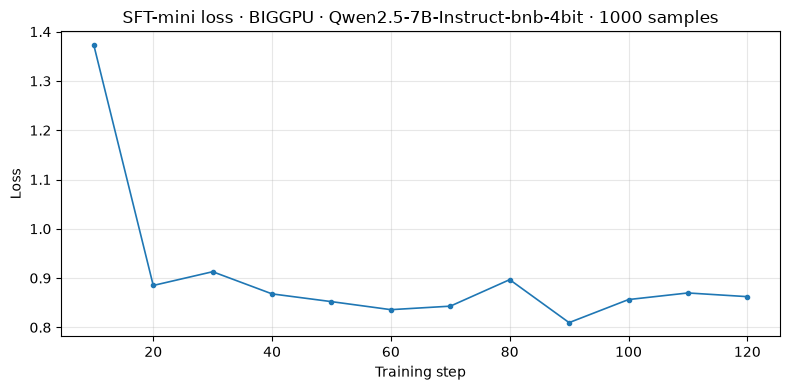

In [9]:
import matplotlib.pyplot as plt

losses = [log["loss"] for log in trainer.state.log_history if "loss" in log]
steps = [log["step"] for log in trainer.state.log_history if "loss" in log]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(steps, losses, marker="o", markersize=3, linewidth=1.2)
ax.set_xlabel("Training step")
ax.set_ylabel("Loss")
ax.set_title(f"SFT-mini loss · {COMPUTE_TIER} · {BASE_MODEL.split('/')[-1]} · {SFT_SLICE} samples")
ax.grid(True, alpha=0.3)
fig.tight_layout()
screenshot_dir = REPO_ROOT / "submission" / "screenshots"
screenshot_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(screenshot_dir / "02-sft-loss.png", dpi=120)
plt.show()

## 4. Save adapter + sanity-check generation

In [10]:
trainer.model.save_pretrained(str(ADAPTER_OUT))
tokenizer.save_pretrained(str(ADAPTER_OUT))
print(f"Saved SFT adapter to {ADAPTER_OUT}")

Saved SFT adapter to /__modal/volumes/vo-QbF7K8KWuDIUX0zRCoBH8Z/lab22/adapters/sft-mini


In [11]:
# Sanity: generate 1 sample to confirm the adapter loaded correctly.
FastLanguageModel.for_inference(model)
prompt = "Giải thích ngắn gọn (3-4 câu) thuật toán quicksort hoạt động thế nào."
messages = [{"role": "user", "content": prompt}]
inputs = tokenizer.apply_chat_template(
    messages, return_tensors="pt", add_generation_prompt=True
).to("cuda")
with torch.no_grad():
    out = model.generate(input_ids=inputs, max_new_tokens=200, do_sample=False)
generated = tokenizer.decode(out[0][inputs.shape[1]:], skip_special_tokens=True)
print(f"PROMPT: {prompt}\n")
print(f"SFT-mini response:\n{generated}")

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


PROMPT: Giải thích ngắn gọn (3-4 câu) thuật toán quicksort hoạt động thế nào.

SFT-mini response:
Thuật toán quicksort là một phương pháp sắp xếp dữ liệu dựa trên nguyên tắc chia nhỏ và thống nhất. Nó chọn một phần tử trong dãy dữ liệu làm điểm phân chia, sau đó sắp xếp các phần tử nhỏ hơn vào một bên và các phần tử lớn hơn vào bên kia. Quá trình này được lặp lại cho từng phần của dãy dữ liệu cho đến khi tất cả các phần tử đã được sắp xếp đúng vị trí.


## 5. Vibe-coding callout

Bạn vừa tái tạo Lab 21 trong ~10 phút. Một câu hỏi để brainstorm:

> **Thật ra, bạn cần *bao nhiêu* SFT để DPO có ý nghĩa?**
>
> Thử thay `SFT_SLICE = 1000` → `100`. Re-run NB1 → NB3 với SFT yếu hơn.
> Quan sát: reward gap có còn tăng được không? Output coherent không?
>
> Đây là 1 design decision *think-hard zone* (xem VIBE-CODING.md): không có
> đáp án sẵn trong deck. Hypothesize trước, train sau, viết kết quả vào
> `submission/REFLECTION.md` § 6.

**Next:** NB2 — load + format preference data.